In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.cluster import DBSCAN
import numpy as np
from geopy.distance import geodesic


In [ ]:
# Loading data and converting types
data = pd.read_csv('Trips_2018/Trips_2018.csv')
data['starttime'] = pd.to_datetime(data['starttime'])
data['stoptime'] = pd.to_datetime(data['stoptime'])

# Creating a dataframe for the stations
stations_start = data[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
stations_start.columns = ['station_id', 'latitude', 'longitude']

stations_end = data[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
stations_end.columns = ['station_id', 'latitude', 'longitude']

# Combine start and end stations
stations = pd.concat([stations_start, stations_end]).drop_duplicates().reset_index(drop=True)


In [63]:

print(data.head())
print(data.columns.tolist())
    

   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

# Analysis

### General

In [65]:
print("##### Data Summary #####")
print("Shape (rows, columns):", data.shape)
print(data.info())
print("\n\n##### Continuous variable information #####")
print(data.describe())
print("\n\n##### Missing Values #####")
print(data.isnull().sum())

##### Data Summary #####
Shape (rows, columns): (17548339, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17548339 entries, 0 to 17548338
Data columns (total 14 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Unnamed: 0               int64  
 1   tripduration             int64  
 2   starttime                object 
 3   stoptime                 object 
 4   start_station_id         float64
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_latitude     float64
 9   end_station_longitude    float64
 10  bikeid                   int64  
 11  usertype                 object 
 12  birth_year               int64  
 13  gender                   int64  
dtypes: float64(6), int64(5), object(3)
memory usage: 1.8+ GB
None


##### Continuous variable information #####
         Unnamed: 0  tripduration  start_station_id  start_station_latitude  \
count  1.754834e+07  1

In [66]:
# Note that we have to use geodesic because lat/lon are not in a Cartesian coordinate system
min_lat = stations['latitude'].min()
max_lat = stations['latitude'].max()
min_lon = stations['longitude'].min()
max_lon = stations['longitude'].max()

bottom_left = (min_lat, min_lon)
top_right = (max_lat, max_lon)

width_km = geodesic((min_lat, min_lon), (min_lat, max_lon)).km
height_km = geodesic((min_lat, min_lon), (max_lat, min_lon)).km
total_area_km2 = width_km * height_km
print(f"Total area covered by stations: {total_area_km2:.2f} km**2")

Total area covered by stations: 23505.95 km**2


In [ ]:
# Check the timespan of the data by examining the min and max start times
print("Start time range:", data['starttime'].min(), "to", data['starttime'].max())

Start time range: 2018-01-01 00:01:50.650000 to 2018-12-31 23:59:51.085000


In [83]:
# How many stations are there in total?
num_stations = stations['station_id'].nunique()
print(f"Number of unique stations: {num_stations}")

Number of unique stations: 850


Text(0.5, 1.0, 'Station Locations Colored by Average Monthly Trips-beginnings')

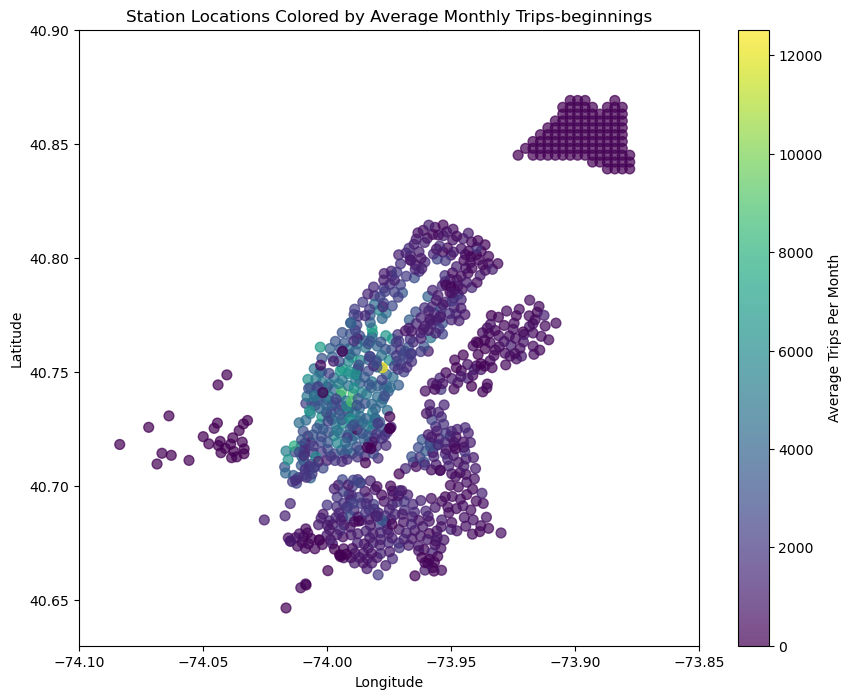

In [72]:
data['starttime'] = pd.to_datetime(data['starttime']) # Convert to datetime
data['year_month'] = data['starttime'].dt.to_period('M') # Extract year-month for grouping
monthly_start_counts = data.groupby(['year_month', 'start_station_id']).size() # Count trips per month per station

# Compute monthly average trip counts per station and map to stations dataframe
avg_monthly_trip_counts = monthly_start_counts.groupby(level=1).mean()
stations_with_trips = stations.copy()
stations_with_trips['avg_monthly_trips'] = stations_with_trips['station_id'].map(avg_monthly_trip_counts).fillna(0)

# Plot the stations colored by average monthly trips
plt.figure(figsize=(10, 8))
plt.scatter(
    stations_with_trips['longitude'],
    stations_with_trips['latitude'],
    c=stations_with_trips['avg_monthly_trips'],
    cmap='viridis',
    s=50,
    alpha=0.7
)
plt.xlim([-74.1, -73.85])
plt.ylim([40.63, 40.9])
plt.colorbar(label='Average Trips Per Month')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Station Locations Colored by Average Monthly Trips-beginnings')


### Null values


First thing is to identify why there are null values. Does the coordinate match any other station with a valid station_id? <br>
    -> No matches found, so there are some stations without IDs or the bikes were started from non-station locations.<br>
    -> We have only 100 unique combinations indicating that the missing values are in fact station they just doesn't have a station ID.


In [68]:
print("\n\n##### Checking for matching stations #####")

# Check if any other station has the same coordinates as the first null start_station_id
first_null_lat = data[data['start_station_id'].isnull()].iloc[0]['start_station_latitude']
first_null_long = data[data['start_station_id'].isnull()].iloc[0]['start_station_longitude']
matching_stations = data[(data['start_station_latitude'] == first_null_lat) & 
                         (data['start_station_longitude'] == first_null_long) & 
                         (data['start_station_id'].notnull())]

print(matching_stations.head())

print("\n\n##### Counting occurrences of null coordinate pairs #####")
# Check how many unique null coordinate pairs exist
null_coords = data[data['start_station_id'].isnull()][['start_station_latitude', 'start_station_longitude']].drop_duplicates()
print("Unique null coordinate pairs:", null_coords.shape[0])

null_coords_counts = (
    data[data['start_station_id'].isnull()]
    .groupby(['start_station_latitude', 'start_station_longitude'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print(null_coords_counts.head(n=100))
print(f"\nTotal unique null coordinate pairs: {null_coords_counts.shape[0]}")




##### Checking for matching stations #####
Empty DataFrame
Columns: [Unnamed: 0, tripduration, starttime, stoptime, start_station_id, start_station_latitude, start_station_longitude, end_station_id, end_station_latitude, end_station_longitude, bikeid, usertype, birth_year, gender, year_month]
Index: []


##### Counting occurrences of null coordinate pairs #####
Unique null coordinate pairs: 100
    start_station_latitude  start_station_longitude  count
78                  40.860                  -73.890    150
68                  40.857                  -73.890    133
69                  40.857                  -73.887    121
70                  40.857                  -73.884     91
83                  40.863                  -73.902     78
..                     ...                      ...    ...
44                  40.851                  -73.896      2
38                  40.851                  -73.914      1
37                  40.851                  -73.917      1
9         

### Outliers in position

Using DBSCAN, we detected two stations that are classified as outliers because they are not density-reachable from any core point. These two stations are only about 45 kilometers apart, and considering that the dataset spans an area of approximately 23,505.95 km², it is reasonable to group them together in an additional (k+1)th cluster for the clustering task.

In [ ]:
coords = stations[['latitude', 'longitude']].to_numpy()

coords = np.radians(coords)  # convert degrees to radians
db = DBSCAN(eps=0.0005, min_samples=5, metric='haversine').fit(coords)

labels = db.labels_
outliers = stations[labels == -1]

print(f"Found {len(outliers)} outliers")
print(outliers)

outlier_coords = outliers[['latitude', 'longitude']].to_numpy()
dist = geodesic(outlier_coords[0], outlier_coords[1]).meters
print(f"The distance between the two outliers is {dist} meters")



Found 2 outliers
     station_id   latitude  longitude
607      3488.0  45.506364 -73.569463
752      3650.0  45.506264 -73.568906
The distance between the two outliers is 44.99000090377168 meters


### Checking for stationarity

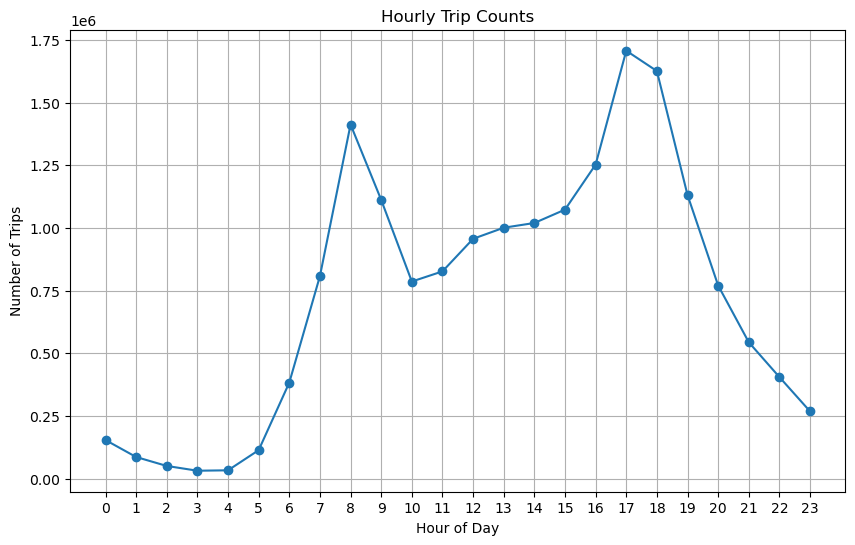

In [80]:
# We want to check for seasonality in the trip data based on start times on an hourly basis
data['hour'] = data['starttime'].dt.hour
hourly_trip_counts = data.groupby('hour').size()
plt.figure(figsize=(10, 6))
plt.plot(hourly_trip_counts.index, hourly_trip_counts.values, marker='o')
plt.title('Hourly Trip Counts')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid()
plt.show()



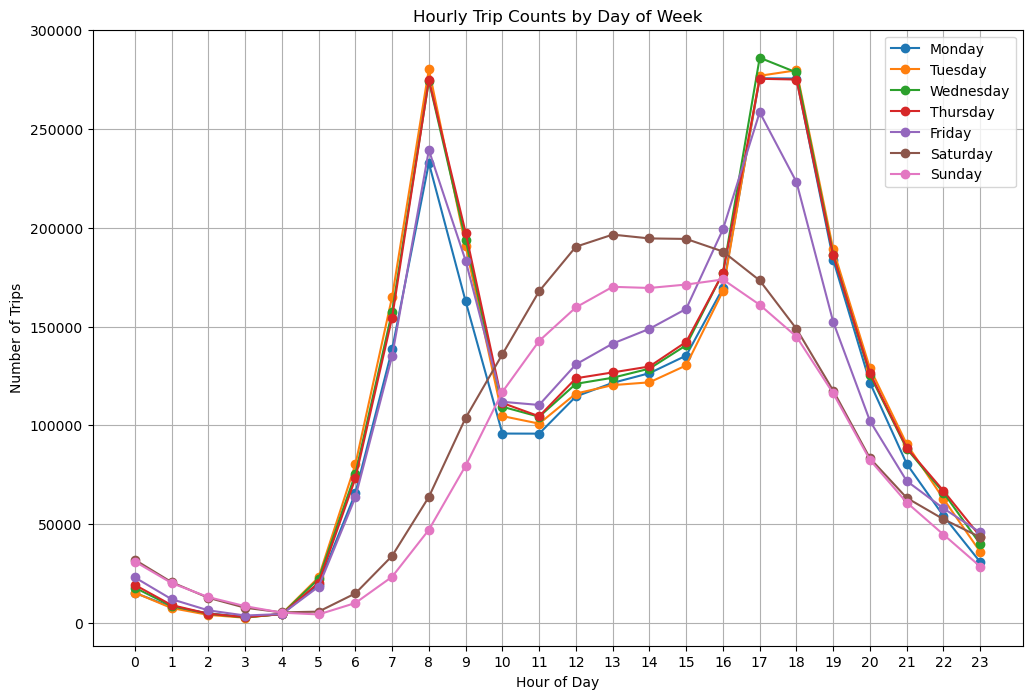

In [81]:
# Now we want to expand this, still looking at an hourly basis, but now looking at each day of the week
data['day_of_week'] = data['starttime'].dt.day_name()
hourly_daily_trip_counts = data.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 8))
for day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']:
    plt.plot(hourly_daily_trip_counts.columns, hourly_daily_trip_counts.loc[day], marker='o', label=day)
plt.title('Hourly Trip Counts by Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.legend()
plt.grid()
plt.show()

C:\Users\huste\AppData\Local\Temp\ipykernel_14272\3871903248.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_daily_trip_counts = data.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)


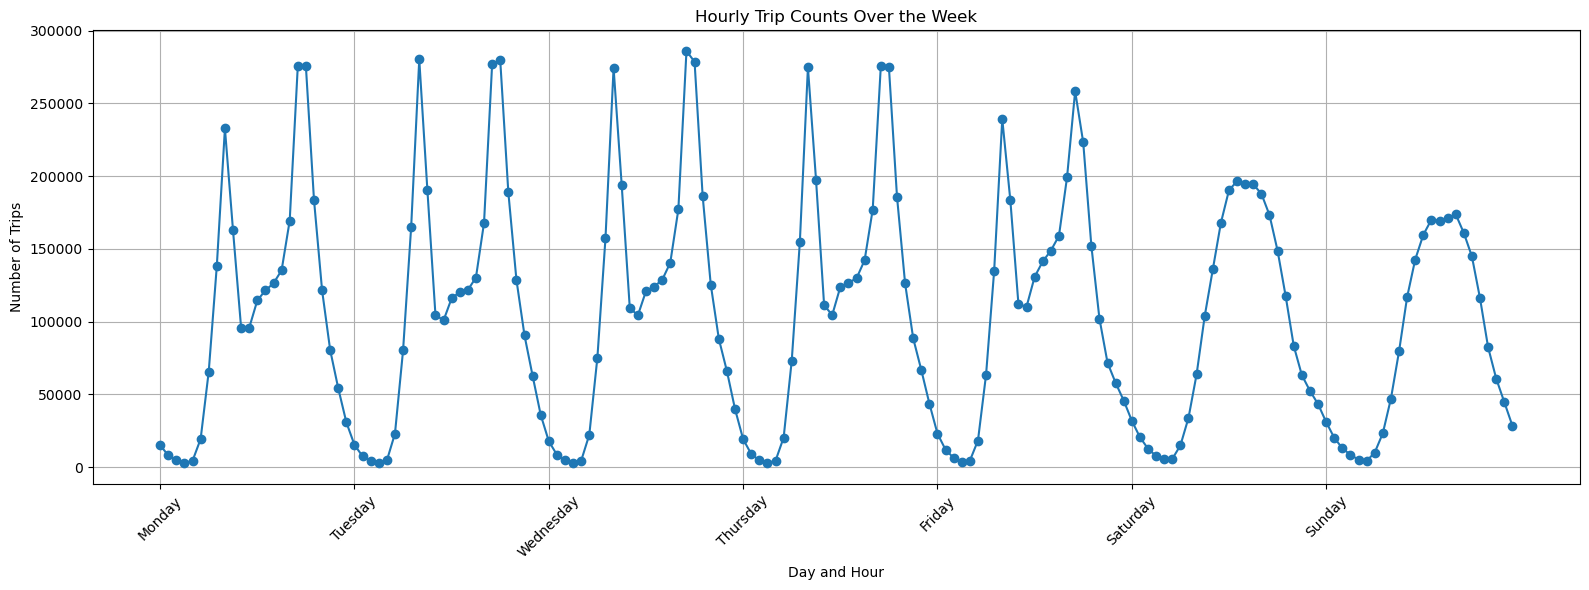

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Grouping of day/hour
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data['day_of_week'] = pd.Categorical(data['starttime'].dt.day_name(), categories=day_order, ordered=True)
hourly_daily_trip_counts = data.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)

# Flatten data into one continuous timeline
continuous_counts = []
x_labels = []
for i, day in enumerate(day_order):
    continuous_counts.extend(hourly_daily_trip_counts.loc[day])
    x_labels.extend([f"{day[:3]} {h}:00" for h in range(24)])  # Optional: readable labels

plt.figure(figsize=(16, 6))
plt.plot(range(len(continuous_counts)), continuous_counts, marker='o')
plt.title('Hourly Trip Counts Over the Week')
plt.xlabel('Day and Hour')
plt.ylabel('Number of Trips')
plt.xticks(
    ticks=[i*24 for i in range(7)],
    labels=day_order,
    rotation=45
)
plt.grid()
plt.tight_layout()
plt.show()


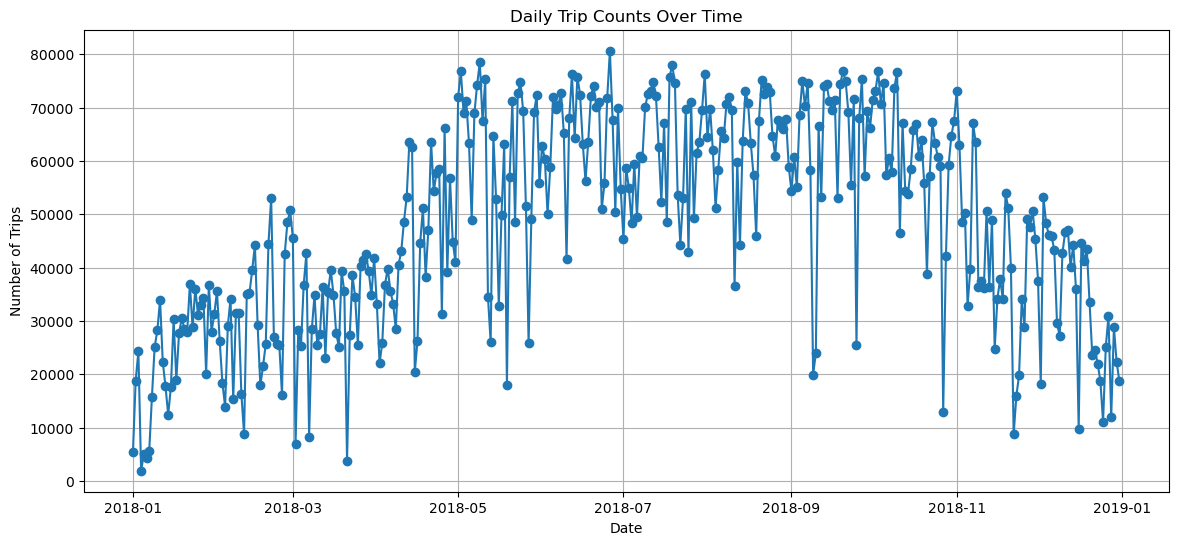

In [88]:
# Show daiyly aggregated trip counts over the entire period
daily_trip_counts = data.groupby(data['starttime'].dt.date).size()
plt.figure(figsize=(14, 6))
plt.plot(daily_trip_counts.index, daily_trip_counts.values, marker='o')
plt.title('Daily Trip Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.grid()
plt.show()



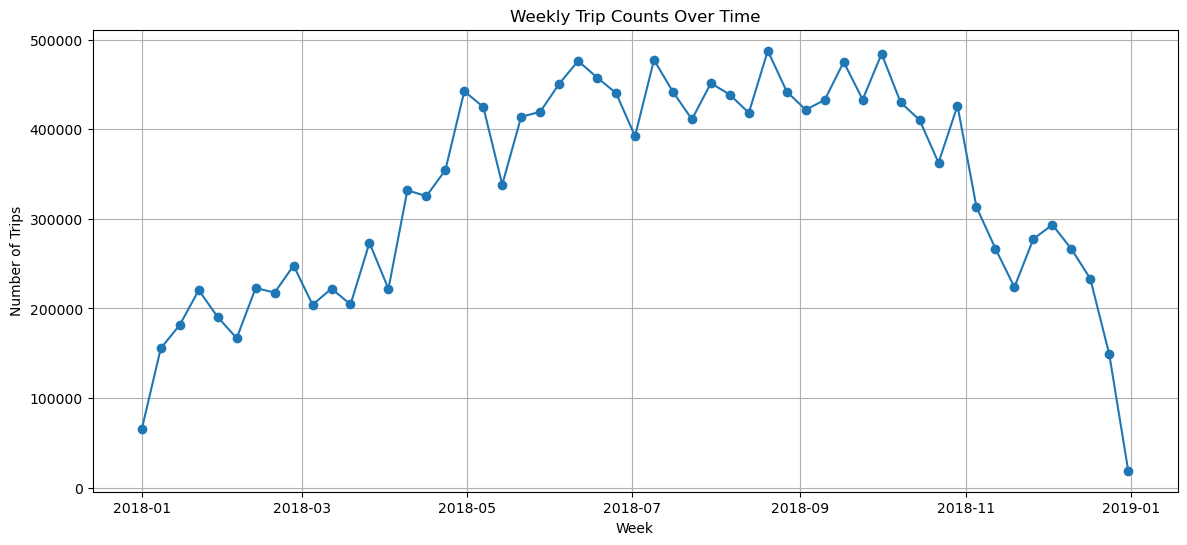

In [87]:
# Show weekly aggregated trip counts over the entire period
weekly_trip_counts = data.groupby(data['starttime'].dt.to_period('W')).size()
plt.figure(figsize=(14, 6))
plt.plot(weekly_trip_counts.index.to_timestamp(), weekly_trip_counts.values, marker='o')
plt.title('Weekly Trip Counts Over Time')
plt.xlabel('Week')
plt.ylabel('Number of Trips')
plt.grid()
plt.show()

### Missing bikes

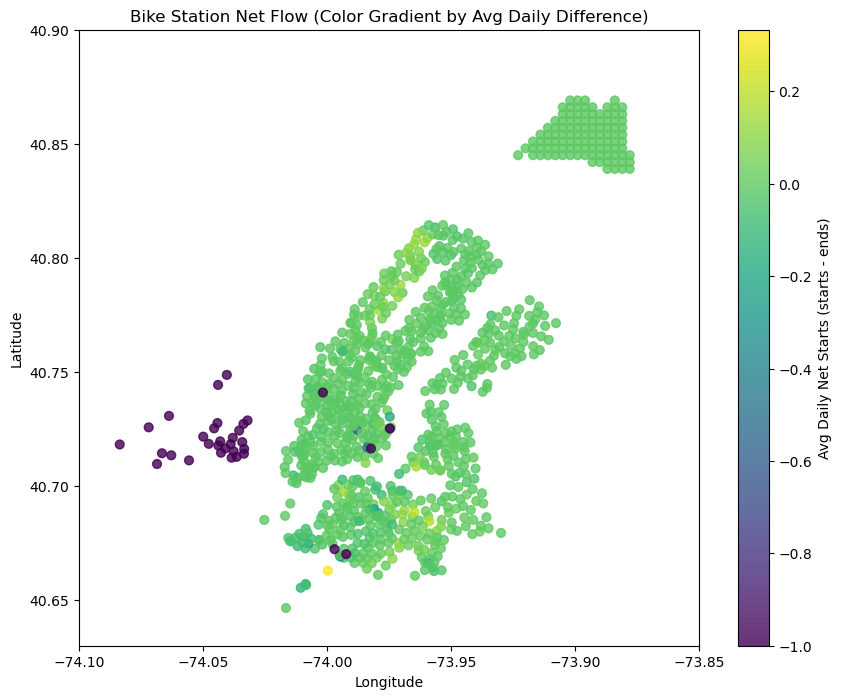

In [ ]:
# Get the average daily missing bikes per station
daily_starts = (
    data.groupby(['starttime', 'start_station_id'])
        .size()
        .reset_index(name='starts')
        .rename(columns={'start_station_id': 'station_id'})
)
daily_ends = (
    data.groupby(['starttime', 'end_station_id'])
        .size()
        .reset_index(name='ends')
        .rename(columns={'end_station_id': 'station_id'})
)
daily = pd.merge(daily_starts, daily_ends, on=['starttime','station_id'], how='outer').fillna(0)
avg_daily = (
    daily.groupby('station_id')[['starts','ends']]
         .mean()
         .reset_index()
         .rename(columns={'starts':'avg_daily_starts','ends':'avg_daily_ends'})
)
avg_daily['avg_daily_diff'] = avg_daily['avg_daily_starts'] - avg_daily['avg_daily_ends']

# Merge avg_daily_diff into station data
plot_df = stations.merge(avg_daily[['station_id', 'avg_daily_diff']], on='station_id', how='left')
plot_df['avg_daily_diff'] = plot_df['avg_daily_diff'].fillna(0)

plt.figure(figsize=(10, 8))

# Scatter by avg_daily_diff with color gradient
sc = plt.scatter(
    plot_df['longitude'],
    plot_df['latitude'],
    c=plot_df['avg_daily_diff'],
    cmap='viridis', 
    s=40,
    alpha=0.8
)

plt.colorbar(sc, label='Avg Daily Net Starts (starts - ends)')
plt.xlim([-74.1, -73.85])
plt.ylim([40.63, 40.9])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Bike Station Net Flow (Color Gradient by Avg Daily Difference)')
plt.show()


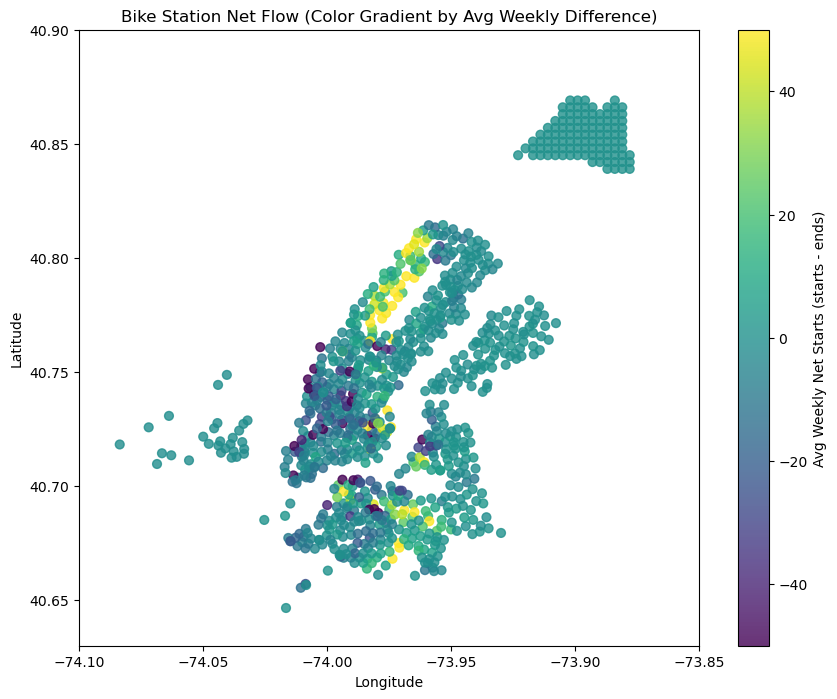

In [ ]:
# Get weekly starts and ends per station
data['week'] = data['starttime'].dt.to_period('W')
weekly_starts = (
    data.groupby(['week', 'start_station_id'])
        .size()
        .reset_index(name='starts')
        .rename(columns={'start_station_id': 'station_id'})
)
weekly_ends = (
    data.groupby(['week', 'end_station_id'])
        .size()
        .reset_index(name='ends')
        .rename(columns={'end_station_id': 'station_id'})
)
weekly = pd.merge(weekly_starts, weekly_ends, on=['week','station_id'], how='outer').fillna(0)

# Average weekly stats per station
avg_weekly = (
    weekly.groupby('station_id')[['starts','ends']]
          .mean()
          .reset_index()
          .rename(columns={
              'starts':'avg_weekly_starts',
              'ends':'avg_weekly_ends'
          })
)
avg_weekly['avg_weekly_diff'] = avg_weekly['avg_weekly_starts'] - avg_weekly['avg_weekly_ends']

# Merge into station data
plot_df = stations.merge(avg_weekly[['station_id', 'avg_weekly_diff']], on='station_id', how='left')
plot_df['avg_weekly_diff'] = plot_df['avg_weekly_diff'].fillna(0)

plt.figure(figsize=(10, 8))

# Scatter by avg_weekly_diff with color gradient
sc = plt.scatter(
    plot_df['longitude'],
    plot_df['latitude'],
    c=plot_df['avg_weekly_diff'],
    cmap='viridis',
    s=40,
    alpha=0.8,
    vmin=-50,   # <-- lower bound of color scale
    vmax=50     # <-- upper bound of color scale
)

plt.colorbar(sc, label='Avg Weekly Net Starts (starts - ends)')
plt.xlim([-74.1, -73.85])
plt.ylim([40.63, 40.9])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Bike Station Net Flow (Color Gradient by Avg Weekly Difference)')
plt.show()
